In [3]:
# # ============================================
# # EXAMPLE 1: BASIC USAGE WITH CORE PARAMETERS
# # ============================================

# # REGRESSION EXAMPLE
# reg_model = xgb.XGBRegressor(
#     # Tree-specific parameters
#     n_estimators=100,      # Number of boosting rounds (trees)
#     max_depth=6,           # Maximum tree depth (deeper = more complex)
#     min_child_weight=1,    # Minimum sum of instance weights in a child
    
#     # Learning parameters
#     learning_rate=0.3,     # Step size shrinkage (eta)
#     subsample=1.0,         # Fraction of samples per tree
#     colsample_bytree=1.0,  # Fraction of features per tree
    
#     # Regularization
#     gamma=0,               # Minimum loss reduction for split
#     reg_alpha=0,           # L1 regularization (Lasso)
#     reg_lambda=1,          # L2 regularization (Ridge)
    
#     # Task parameters
#     objective='reg:squarederror',  # Loss function
#     random_state=42
# )

# # CLASSIFICATION EXAMPLE
# clf_model = xgb.XGBClassifier(
#     # Same tree parameters
#     n_estimators=100,
#     max_depth=6,
#     min_child_weight=1,
#     learning_rate=0.3,
#     subsample=1.0,
#     colsample_bytree=1.0,
#     gamma=0,
#     reg_alpha=0,
#     reg_lambda=1,
    
#     # Different objective for classification
#     objective='binary:logistic',  # For binary classification
#     eval_metric='logloss',        # Evaluation metric
#     random_state=42
# )

# print("Basic models created successfully!")

In [4]:
## Classification example
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.datasets import load_breast_cancer
from sklearn.metrics import accuracy_score, confusion_matrix
from xgboost import XGBClassifier
import xgboost as xgb

In [5]:
## classification example
from sklearn.datasets import make_classification

X, y = make_classification(n_samples= 1000, n_features= 20 ,n_informative=3, random_state= 42)
X_train , X_test, y_train, y_test = train_test_split(X, y,test_size= 0.3)

In [6]:
clf = XGBClassifier(
    n_estimators = 100,
    learning_rate = 0.1,
    max_depth = 4, 
    objective = 'binary:logistic', 
    eval_metric = 'logloss'
)
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)
accuracy_score(y_test, y_pred)

0.92

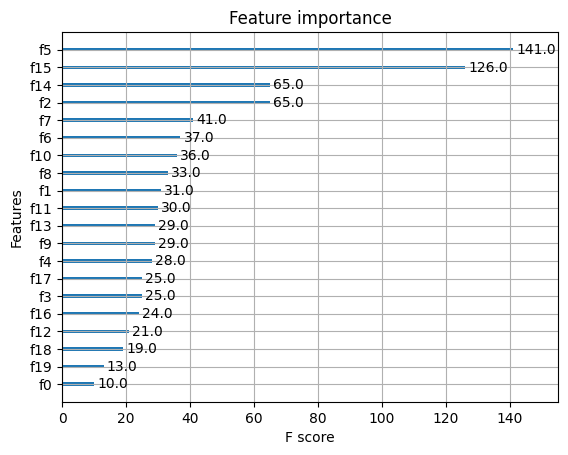

In [7]:
##very useful
import matplotlib.pyplot as plt
%matplotlib inline
xgb.plot_importance(clf)
plt.show()

In [15]:
## let's try on other dataset
from sklearn.datasets import load_breast_cancer
data = load_breast_cancer()
X = pd.DataFrame(data.data, columns= data.feature_names)
y = data.target

In [16]:
X_train, X_test, y_train, y_test =train_test_split(X, y, train_size= 0.3, stratify= y,random_state= 42)

In [17]:
clf.fit(X_train, y_train)
y_pred_breast = clf.predict(X_test)
accuracy_score(y_test, y_pred_breast)

0.9573934837092731

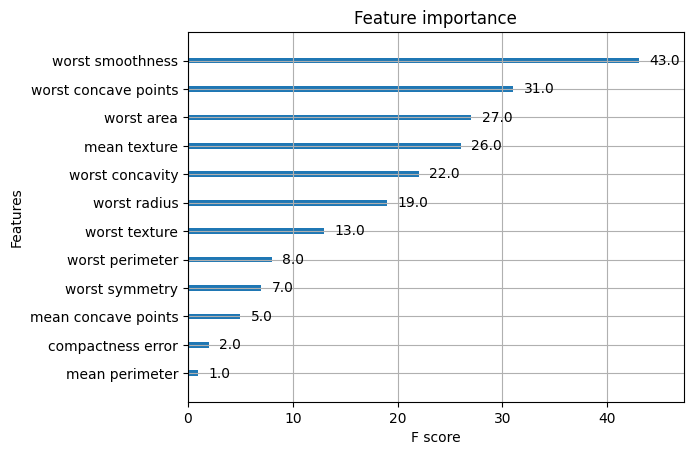

In [ ]:
xgb.plot_importance(clf)
plt.show()
# The F score (often labeled as F or Weight) in XGBoost's importance plot represents how many times a feature is used to split the data across all trees.


In [24]:
## let's try on Regression
from sklearn.datasets import fetch_california_housing
from sklearn.metrics import root_mean_squared_error
from xgboost import XGBRegressor

data = fetch_california_housing()
X = pd.DataFrame(data.data, columns= data.feature_names)
y = data.target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size= 0.3, random_state= 42)


In [27]:
model = XGBRegressor(
    n_estimators = 100,
    learning_rate = 0.1,
    max_depth = 5,
    subsample = 0.8,
    colsample_bytree = 0.8,
    objective = 'reg:squarederror',
    random_state = 42
)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
root_mean_squared_error(y_test, y_pred)


np.float64(0.480483336457948)

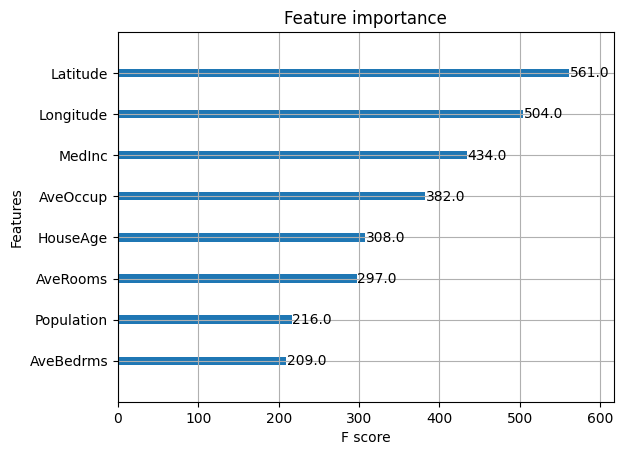

In [30]:
xgb.plot_importance(model, importance_type='weight')
plt.show()